In [1]:
# Celda 1: Importar librerías
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Agregar carpeta raíz al path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

from cargar_datos import cargar_dataset_recontacto, cargar_dataset_recontacto_correcto
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from xgboost import XGBClassifier

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ Librerías cargadas correctamente")


✅ Librerías cargadas correctamente


In [2]:
# Celda 2: Cargar el dataset SUCIO (v0)
print("=" * 70)
print("📊 CARGANDO DATASET v0 (SUCIO, tal como llegó)")
print("=" * 70)
df_sucio = cargar_dataset_recontacto()
print(f"\n✅ Dataset sucio: {df_sucio.shape[0]:,} registros")

# Cargar el dataset LIMPIO (v1, después del MINI ETL)
print("\n" + "=" * 70)
print("📊 CARGANDO DATASET v1 (CORREGIDO, después del MINI ETL)")
print("=" * 70)
df_limpio = cargar_dataset_recontacto_correcto()
print(f"\n✅ Dataset limpio: {df_limpio.shape[0]:,} registros")

print("\n" + "=" * 70)
print("📋 COMPARACIÓN DE DIMENSIONES")
print("=" * 70)
print(f"Dataset sucio (v0): {df_sucio.shape[0]:,} filas × {df_sucio.shape[1]} columnas")
print(f"Dataset limpio(v1): {df_limpio.shape[0]:,} filas × {df_limpio.shape[1]} columnas")
print(f"\nRegistros que el MINI ETL rechazó o deduplicó: {df_sucio.shape[0] - df_limpio.shape[0]:,}")


📊 CARGANDO DATASET v0 (SUCIO, tal como llegó)
📊 CARGANDO DATASET v0 DE RECONTACTO (SUCIO)



📏 Dataset v0 (sucio): 98,317 filas × 29 columnas

🎯 Distribución de la variable objetivo (recontacto_7_dias):
recontacto_7_dias
0    57890
1    40427
Name: count, dtype: int64

📈 Tasa de recontacto_7_dias=1: 41.12%

✅ Dataset sucio: 98,317 registros

📊 CARGANDO DATASET v1 (CORREGIDO, después del MINI ETL)
📊 CARGANDO DATASET v1 CORREGIDO DE RECONTACTO (LIMPIO)



📏 Dataset v1 (limpio): 94,065 filas × 29 columnas

🎯 Distribución de la variable objetivo (recontacto_7_dias):
recontacto_7_dias
0    55324
1    38741
Name: count, dtype: int64

📈 Tasa de recontacto_7_dias=1: 41.19%

✅ Dataset limpio: 94,065 registros

📋 COMPARACIÓN DE DIMENSIONES
Dataset sucio (v0): 98,317 filas × 29 columnas
Dataset limpio(v1): 94,065 filas × 29 columnas

Registros que el MINI ETL rechazó o deduplicó: 4,252


In [3]:
# Celda 3: Función reutilizable para entrenar el mismo modelo en ambos datasets
def entrenar_y_evaluar(df, nombre_dataset):
    print(f"\n{'=' * 70}")
    print(f"🤖 ENTRENANDO MODELO: {nombre_dataset}")
    print(f"{'=' * 70}")

    # 1. Preparar variables
    columnas_a_eliminar = ['id_interaccion', 'fecha_contacto', 'recontacto_7_dias']
    X = df.drop(columns=columnas_a_eliminar, errors='ignore').apply(pd.to_numeric)
    y = df['recontacto_7_dias'].astype(int)

    # 2. Codificar categóricas si quedan y rellenar nulos
    columnas_texto = X.select_dtypes(include=['object']).columns
    if len(columnas_texto) > 0:
        X = pd.get_dummies(X, columns=columnas_texto.tolist(), drop_first=True)
    X = X.astype({col: 'int8' for col in X.select_dtypes(include=['bool']).columns})
    X = X.fillna(0)

    # 3. Dividir train/test
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.20, random_state=42, stratify=y
    )

    print(f"📏 Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}")
    print(f"📊 Features: {X.shape[1]}")

    # 4. Entrenar el MISMO modelo en ambos casos
    ratio_desbalance = (y_train == 0).sum() / (y_train == 1).sum()
    modelo = XGBClassifier(
        n_estimators=600,
        max_depth=5,
        learning_rate=0.05,
        scale_pos_weight=ratio_desbalance,
        random_state=42,
        eval_metric='auc',
        verbosity=0
    )
    modelo.fit(X_train, y_train)

    # 5. Evaluar
    y_pred = modelo.predict(X_test)
    y_pred_proba = modelo.predict_proba(X_test)[:, 1]
    accuracy = (y_pred == y_test).mean()
    auc = roc_auc_score(y_test, y_pred_proba)

    print(f"\n📊 MÉTRICAS:")
    print(f"   Accuracy: {accuracy:.4f}")
    print(f"   ROC-AUC:  {auc:.4f}")

    importancia = pd.DataFrame({
        'Variable': X.columns,
        'Importancia': modelo.feature_importances_
    }).sort_values(by='Importancia', ascending=False)

    return {
        'modelo': modelo, 'X_test': X_test, 'y_test': y_test, 'y_pred': y_pred,
        'y_pred_proba': y_pred_proba, 'accuracy': accuracy, 'auc': auc,
        'importancia': importancia, 'nombre': nombre_dataset
    }


In [4]:
# Celda 4: Entrenar ambos modelos (mismos hiperparámetros, misma semilla)
resultados_sucio = entrenar_y_evaluar(df_sucio, "SUCIO (v0, antes del MINI ETL)")
resultados_limpio = entrenar_y_evaluar(df_limpio, "LIMPIO (v1, después del MINI ETL)")



🤖 ENTRENANDO MODELO: SUCIO (v0, antes del MINI ETL)


📏 Train: 78,653 | Test: 19,664
📊 Features: 26



📊 MÉTRICAS:
   Accuracy: 0.6262
   ROC-AUC:  0.6667

🤖 ENTRENANDO MODELO: LIMPIO (v1, después del MINI ETL)


📏 Train: 75,252 | Test: 18,813
📊 Features: 26



📊 MÉTRICAS:
   Accuracy: 0.6229
   ROC-AUC:  0.6602


📊 COMPARACIÓN DE MÉTRICAS: SUCIO vs LIMPIO
 Métrica Sucio (v0) Limpio (v1)
Accuracy     0.6262      0.6229
 ROC-AUC     0.6667      0.6602


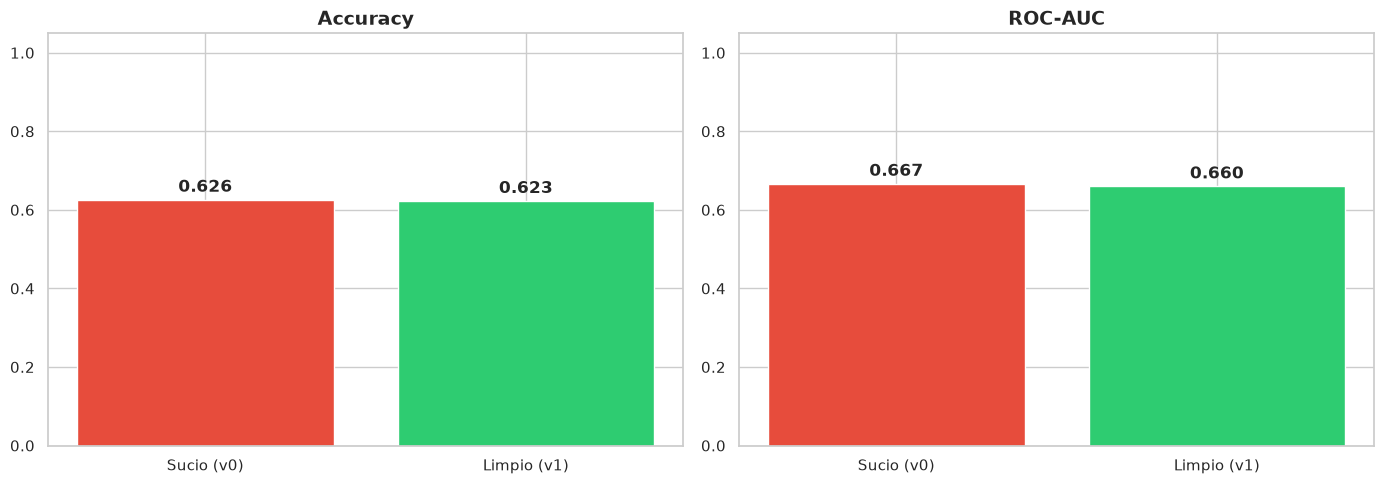


🔍 INTERPRETACIÓN (leer con cuidado):
• Dataset SUCIO:  AUC = 0.6667 (19,664 filas de prueba)
• Dataset LIMPIO: AUC = 0.6602 (18,813 filas de prueba)

⚠️ Que el dataset sucio saque un AUC parecido (o incluso mayor) NO significa que sea mejor:
   1. Los duplicados pueden quedar repartidos entre train y test: la misma interacción
      se usa para entrenar y para evaluar -> fuga de información y métricas infladas.
   2. Las etiquetas COBRO/QUEJA no coinciden con el catálogo y quedan como categoría vacía.
   3. Los valores fuera de rango (duración 2700 s, espera 2000 s...) ensucian las escalas.
Por eso el dataset oficial para el modelo es dm_dataset_recontacto_correcto (v1):
es el único auditable y reproducible. La evidencia está en data/v0_crudo.csv y data/v1_limpio.csv.


In [5]:
# Celda 5: Comparación visual de métricas
print("=" * 70)
print("📊 COMPARACIÓN DE MÉTRICAS: SUCIO vs LIMPIO")
print("=" * 70)

comparacion = pd.DataFrame({
    'Métrica': ['Accuracy', 'ROC-AUC'],
    'Sucio (v0)': [
        f"{resultados_sucio['accuracy']:.4f}",
        f"{resultados_sucio['auc']:.4f}"
    ],
    'Limpio (v1)': [
        f"{resultados_limpio['accuracy']:.4f}",
        f"{resultados_limpio['auc']:.4f}"
    ]
})
print(comparacion.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(['Sucio (v0)', 'Limpio (v1)'],
            [resultados_sucio['accuracy'], resultados_limpio['accuracy']],
            color=['#e74c3c', '#2ecc71'])
axes[0].set_title('Accuracy', fontsize=14, fontweight='bold')
axes[0].set_ylim(0, 1.05)
for i, v in enumerate([resultados_sucio['accuracy'], resultados_limpio['accuracy']]):
    axes[0].text(i, v + 0.02, f"{v:.3f}", ha='center', fontweight='bold')

axes[1].bar(['Sucio (v0)', 'Limpio (v1)'],
            [resultados_sucio['auc'], resultados_limpio['auc']],
            color=['#e74c3c', '#2ecc71'])
axes[1].set_title('ROC-AUC', fontsize=14, fontweight='bold')
axes[1].set_ylim(0, 1.05)
for i, v in enumerate([resultados_sucio['auc'], resultados_limpio['auc']]):
    axes[1].text(i, v + 0.02, f"{v:.3f}", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("🔍 INTERPRETACIÓN (leer con cuidado):")
print("=" * 70)
print(f"• Dataset SUCIO:  AUC = {resultados_sucio['auc']:.4f} ({resultados_sucio['X_test'].shape[0]:,} filas de prueba)")
print(f"• Dataset LIMPIO: AUC = {resultados_limpio['auc']:.4f} ({resultados_limpio['X_test'].shape[0]:,} filas de prueba)")
print()
print("⚠️ Que el dataset sucio saque un AUC parecido (o incluso mayor) NO significa que sea mejor:")
print("   1. Los duplicados pueden quedar repartidos entre train y test: la misma interacción")
print("      se usa para entrenar y para evaluar -> fuga de información y métricas infladas.")
print("   2. Las etiquetas COBRO/QUEJA no coinciden con el catálogo y quedan como categoría vacía.")
print("   3. Los valores fuera de rango (duración 2700 s, espera 2000 s...) ensucian las escalas.")
print("Por eso el dataset oficial para el modelo es dm_dataset_recontacto_correcto (v1):")
print("es el único auditable y reproducible. La evidencia está en data/v0_crudo.csv y data/v1_limpio.csv.")


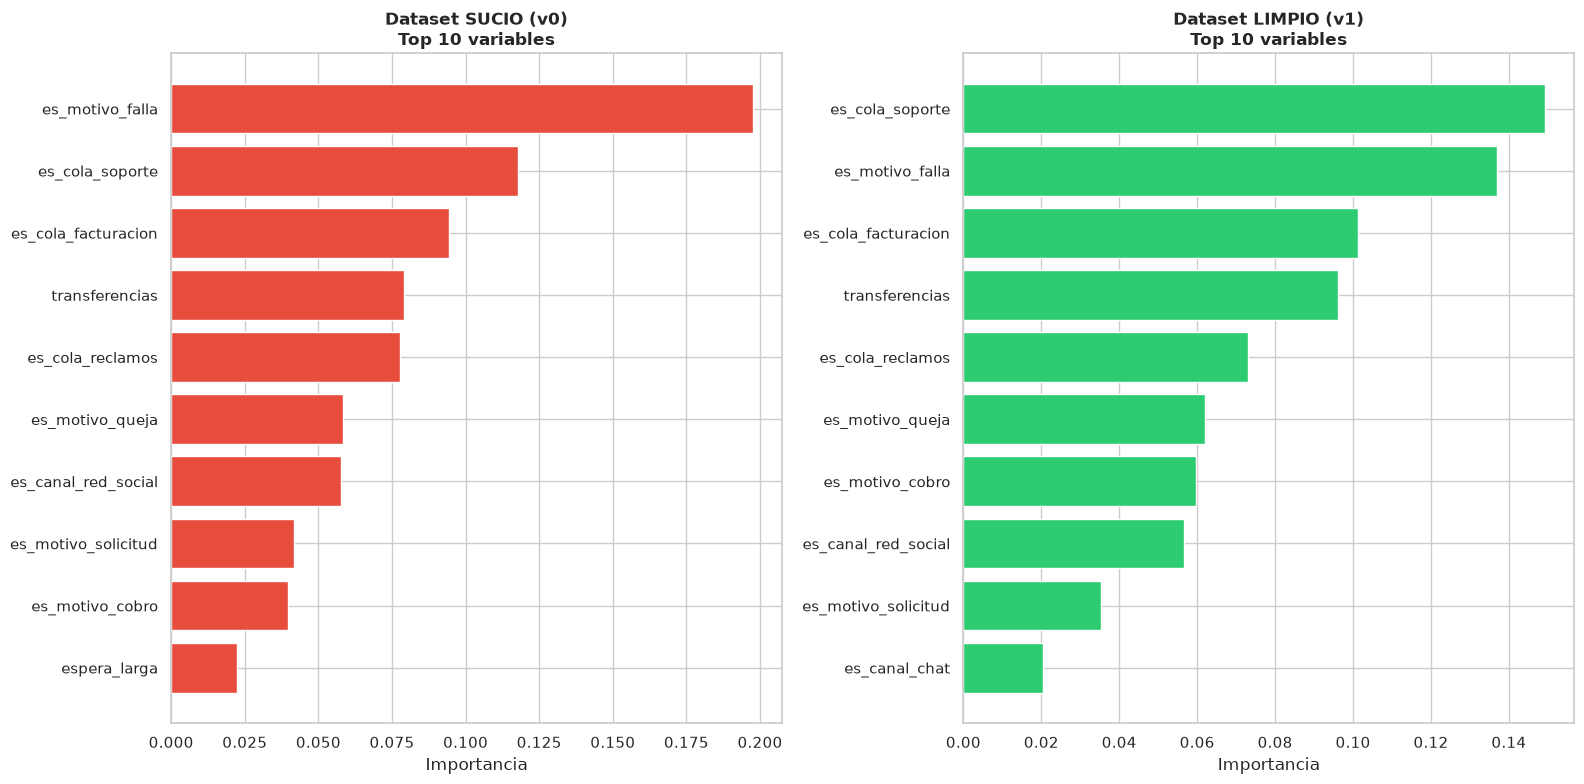

📋 TOP 10 VARIABLES - COMPARACIÓN
 Rank      Variable Sucio  Importancia Sucio     Variable Limpio  Importancia Limpio
    1     es_motivo_falla             0.1975     es_cola_soporte              0.1492
    2     es_cola_soporte             0.1178     es_motivo_falla              0.1368
    3 es_cola_facturacion             0.0945 es_cola_facturacion              0.1012
    4      transferencias             0.0789      transferencias              0.0962
    5    es_cola_reclamos             0.0777    es_cola_reclamos              0.0731
    6     es_motivo_queja             0.0585     es_motivo_queja              0.0619
    7 es_canal_red_social             0.0578     es_motivo_cobro              0.0596
    8 es_motivo_solicitud             0.0417 es_canal_red_social              0.0566
    9     es_motivo_cobro             0.0396 es_motivo_solicitud              0.0354
   10        espera_larga             0.0223       es_canal_chat              0.0205


In [6]:
# Celda 6: Comparar las variables más importantes en cada caso
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

top10_sucio = resultados_sucio['importancia'].head(10)
axes[0].barh(top10_sucio['Variable'][::-1], top10_sucio['Importancia'][::-1], color='#e74c3c')
axes[0].set_title('Dataset SUCIO (v0)\nTop 10 variables', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Importancia')

top10_limpio = resultados_limpio['importancia'].head(10)
axes[1].barh(top10_limpio['Variable'][::-1], top10_limpio['Importancia'][::-1], color='#2ecc71')
axes[1].set_title('Dataset LIMPIO (v1)\nTop 10 variables', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Importancia')

plt.tight_layout()
plt.show()

print("=" * 70)
print("📋 TOP 10 VARIABLES - COMPARACIÓN")
print("=" * 70)
comparacion_vars = pd.DataFrame({
    'Rank': range(1, 11),
    'Variable Sucio': top10_sucio['Variable'].values,
    'Importancia Sucio': top10_sucio['Importancia'].values.round(4),
    'Variable Limpio': top10_limpio['Variable'].values,
    'Importancia Limpio': top10_limpio['Importancia'].values.round(4)
})
print(comparacion_vars.to_string(index=False))


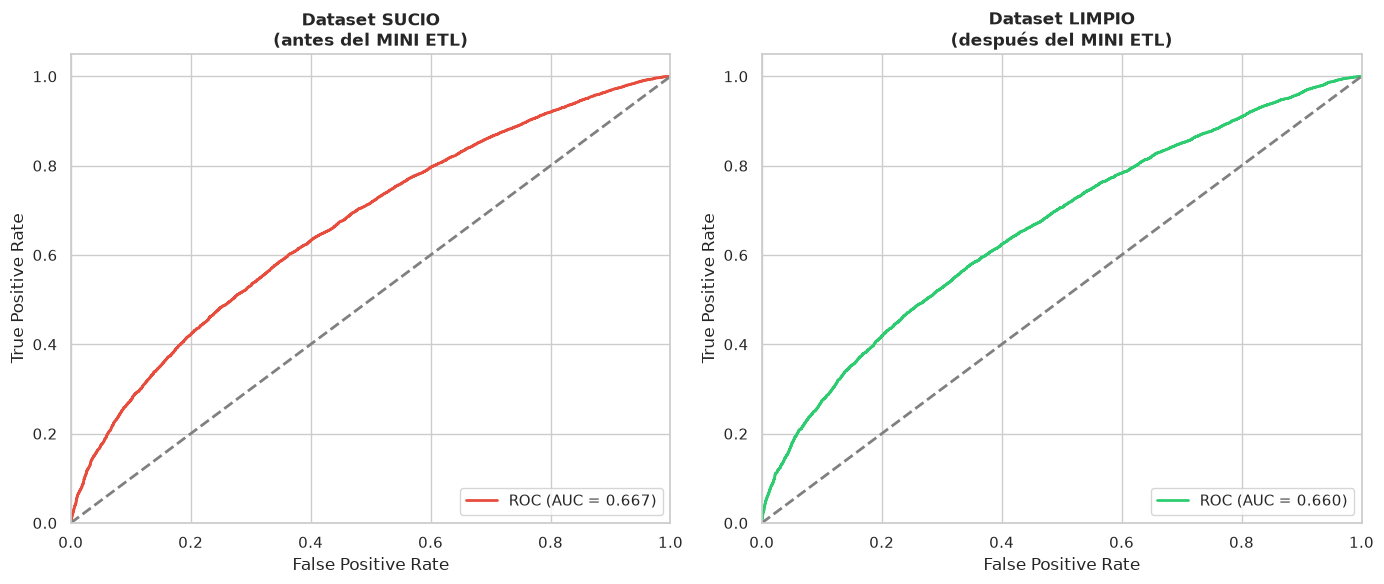

In [7]:
# Celda 7: Curvas ROC lado a lado
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

fpr_s, tpr_s, _ = roc_curve(resultados_sucio['y_test'], resultados_sucio['y_pred_proba'])
axes[0].plot(fpr_s, tpr_s, color='#e74c3c', lw=2, label=f"ROC (AUC = {resultados_sucio['auc']:.3f})")
axes[0].plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
axes[0].set_xlim([0.0, 1.0]); axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('Dataset SUCIO\n(antes del MINI ETL)', fontweight='bold')
axes[0].legend(loc="lower right")

fpr_l, tpr_l, _ = roc_curve(resultados_limpio['y_test'], resultados_limpio['y_pred_proba'])
axes[1].plot(fpr_l, tpr_l, color='#2ecc71', lw=2, label=f"ROC (AUC = {resultados_limpio['auc']:.3f})")
axes[1].plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
axes[1].set_xlim([0.0, 1.0]); axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Dataset LIMPIO\n(después del MINI ETL)', fontweight='bold')
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()


In [8]:
# Celda 8: Reporte ejecutivo
print("=" * 70)
print("📊 REPORTE EJECUTIVO: IMPACTO DE LA CALIDAD DE LOS DATOS")
print("=" * 70)

print(f'''
🔴 DATASET SUCIO (v0, tal como llega de ACD/CRM/Ticketing/Calidad):
   • Registros: {len(df_sucio):,} (incluye duplicados y filas inválidas)
   • Accuracy: {resultados_sucio['accuracy']:.2%}
   • ROC-AUC:  {resultados_sucio['auc']:.4f}
   • Variable #1: {resultados_sucio['importancia'].iloc[0]['Variable']}

🟢 DATASET LIMPIO (v1, después del MINI ETL):
   • Registros: {len(df_limpio):,} (deduplicados y validados)
   • Accuracy: {resultados_limpio['accuracy']:.2%}
   • ROC-AUC:  {resultados_limpio['auc']:.4f}
   • Variable #1: {resultados_limpio['importancia'].iloc[0]['Variable']}

💡 CONCLUSIÓN:
   Los dos modelos pueden dar números parecidos de Accuracy/ROC-AUC. La diferencia
   NO está en "quién saca más", sino en la CONFIANZA que merece cada resultado:
   el dataset sucio tiene duplicados que pueden filtrarse entre entrenamiento y
   prueba (por eso hasta puede salir "mejor" y no es de fiar) y categorías que
   quedan vacías por etiquetas mal escritas.

   El MINI ETL del generador C# deja evidencia en data/v0_crudo.csv y
   data/v1_limpio.csv (regla del profe Eddy: hay que demostrar cuántos registros
   se limpiaron y por qué). El dataset oficial de modelado es
   dm_dataset_recontacto_correcto (v1).
''')

print("=" * 70)
print("✅ ANÁLISIS COMPLETADO")
print("=" * 70)


📊 REPORTE EJECUTIVO: IMPACTO DE LA CALIDAD DE LOS DATOS

🔴 DATASET SUCIO (v0, tal como llega de ACD/CRM/Ticketing/Calidad):
   • Registros: 98,317 (incluye duplicados y filas inválidas)
   • Accuracy: 62.62%
   • ROC-AUC:  0.6667
   • Variable #1: es_motivo_falla

🟢 DATASET LIMPIO (v1, después del MINI ETL):
   • Registros: 94,065 (deduplicados y validados)
   • Accuracy: 62.29%
   • ROC-AUC:  0.6602
   • Variable #1: es_cola_soporte

💡 CONCLUSIÓN:
   Los dos modelos pueden dar números parecidos de Accuracy/ROC-AUC. La diferencia
   NO está en "quién saca más", sino en la CONFIANZA que merece cada resultado:
   el dataset sucio tiene duplicados que pueden filtrarse entre entrenamiento y
   prueba (por eso hasta puede salir "mejor" y no es de fiar) y categorías que
   quedan vacías por etiquetas mal escritas.

   El MINI ETL del generador C# deja evidencia en data/v0_crudo.csv y
   data/v1_limpio.csv (regla del profe Eddy: hay que demostrar cuántos registros
   se limpiaron y por qué). 